<div style="text-align:center; padding: 40px 0 20px 0;">
<h1 style="font-size:2.2em; margin-bottom:0.2em;">📊 Simulador de Livro de Ofertas</h1>
<h2 style="color:#1F4E79; font-weight:normal; margin-top:0;">Relatório de Performance de Estruturas de Dados</h2>
<hr style="border:2px solid #1F4E79; width:60%; margin:1em auto;">
<p style="color:#555; font-size:1.05em;">Disciplina: Estrutura de Dados em Python &nbsp;|&nbsp; Prof. Marcos Mansano Furlan &nbsp;|&nbsp; Semestre 2026</p>
</div>

## 📋 Sumário

1. [Introdução](#introducao)
2. [Estruturas de Dados Utilizadas](#estruturas)
   - 2.1 [Fila de Entrada — Queue (FIFO)](#fila)
   - 2.2 [Livro de Ofertas — Listas Duplamente Encadeadas Ordenadas](#listas)
   - 2.3 [Sistema de Undo — Pilha (LIFO)](#pilha)
3. [Funcionamento do Motor de Match](#match)
4. [Análise de Complexidade Teórica](#complexidade)
5. [Benchmark — Configuração e Execução](#benchmark)
6. [Resultados Empíricos](#resultados)
7. [Gráficos Comparativos](#graficos)
8. [Conclusão](#conclusao)
9. [Repositório GitHub](#github)

In [7]:
import sys
from pathlib import Path

PASTA_ATUAL = Path.cwd().resolve()
if (PASTA_ATUAL / 'src').exists():
    RAIZ_PROJETO = PASTA_ATUAL
elif (PASTA_ATUAL.parent / 'src').exists():
    RAIZ_PROJETO = PASTA_ATUAL.parent
else:
    RAIZ_PROJETO = Path('..').resolve()

sys.path.insert(0, str(RAIZ_PROJETO))

from src.data_structures.linked_list import Linked_List_Compra, Linked_List_Venda
from src.data_structures.node import Node
from src.models.ordem import Ordem
from src.data_structures.queue import Queue
from src.data_structures.stack import Stack
from data.order_generator import gerar_multiplos_csv

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import re


---
## 1. Introdução <a id='introducao'></a>

Este relatório documenta a análise de desempenho do **Simulador de Livro de Ofertas (Order Book)**, desenvolvido para a disciplina de Estrutura de Dados em Python. O trabalho aplica estruturas de dados lineares — **Listas Duplamente Encadeadas**, **Filas (Queue)** e **Pilhas (Stack)** — em um contexto financeiro real, avaliando tanto a **complexidade teórica** quanto o **comportamento empírico** dessas estruturas sob volumes crescentes de dados.

Um **livro de ofertas** é o mecanismo central de qualquer bolsa de valores. Ele mantém, em tempo real, todas as ordens de compra e venda pendentes de um ativo, organizadas por prioridade de preço. O desafio técnico central é garantir que a inserção de novas ordens e o **casamento (match)** entre compradores e vendedores ocorram de forma eficiente mesmo com alto volume de operações.

A escolha das estruturas **lineares** neste projeto é deliberada: além de implementar o sistema funcional, o trabalho busca estabelecer uma **linha de base com complexidade O(n)** para comparação futura com estruturas não-lineares como árvores balanceadas, que reduzem inserção e busca a O(log n).

> **Cada ordem** no sistema possui: `ID`, `Tipo` (C/V), `Preço`, `Quantidade` e `Timestamp`.

---
## 2. Estruturas de Dados Utilizadas <a id='estruturas'></a>

### 2.1 Fila de Entrada — Queue (FIFO) <a id='fila'></a>

A fila de entrada é o **ponto de chegada de todas as ordens** no sistema. Toda ordem nova — de compra ou venda — é imediatamente inserida na fila antes de ser processada pelo motor de match, garantindo atendimento **na ordem exata de chegada** (First-In, First-Out).

A implementação é baseada em **nós encadeados**, mantendo referências ao primeiro (`head`) e ao último (`tail`) elemento. Isso garante complexidade **O(1)** tanto para `enqueue` (inserção no tail) quanto para `dequeue` (remoção do head), sem percorrer a estrutura.

| Operação | Complexidade | Descrição |
|---|:---:|---|
| `enqueue(ordem)` | **O(1)** | Insere nova ordem no final da fila |
| `dequeue()` | **O(1)** | Remove e retorna a primeira ordem |
| `esta_vazia()` | **O(1)** | Verifica se a fila está vazia |

### 2.2 Livro de Ofertas — Listas Duplamente Encadeadas Ordenadas <a id='listas'></a>

O livro de ofertas é composto por **duas listas duplamente encadeadas** mantidas em ordem de prioridade de preço:

- **Lista de Compras:** ordem **decrescente** por preço — o maior comprador (melhor *bid*) fica no início
- **Lista de Vendas:** ordem **crescente** por preço — o menor vendedor (melhor *ask*) fica no início

A **inserção ordenada** exige percorrer a lista até encontrar a posição correta: **O(n)** no pior caso. O encadeamento duplo (`next` e `prev`) permite remoção eficiente em qualquer ponto mediante religamento de ponteiros. A **remoção do início** — operação crítica no match — é sempre **O(1)**.

| Operação | Complexidade | Descrição |
|---|:---:|---|
| `adicionar_no(no)` | **O(n)** | Inserção ordenada — percorre até a posição correta |
| `remover_inicio()` | **O(1)** | Remove o nó de melhor preço (usado no match) |
| `remover_por_id(id)` | **O(n)** | Busca e remove ordem por ID (operação de undo) |

### 2.3 Sistema de Undo — Pilha (LIFO) <a id='pilha'></a>

A pilha de undo armazena os **IDs das ordens** inseridas com sucesso no livro de ofertas. Segue o princípio **LIFO (Last-In, First-Out)**: a última ordem inserida é sempre a primeira a poder ser desfeita — comportamento natural de um sistema de cancelamento.

A implementação em nós garante **O(1)** para `push` e `pop`. A operação de undo completa — que inclui localizar e remover a ordem no livro — tem custo **O(n)** pela busca por ID na lista encadeada.

| Operação | Complexidade | Descrição |
|---|:---:|---|
| `empilhar(id)` | **O(1)** | Registra ID da ordem inserida no livro |
| `desempilhar()` | **O(1)** | Recupera o ID da última ordem inserida |
| `esta_vazia()` | **O(1)** | Verifica se há ações a desfazer |

---
## 3. Funcionamento do Motor de Match <a id='match'></a>

O motor de match é o núcleo do sistema. Seu fluxo para cada ordem:

```
Nova Ordem
    │
    ▼
┌─────────────┐
│ Fila FIFO   │  ← inserir_ordem()
└──────┬──────┘
       │ processar_fila() — dequeue em ordem de chegada
       ▼
┌─────────────────────────────────────────────┐
│  É COMPRA?  preço_compra >= melhor_venda?   │
│  É VENDA?   preço_venda  <= melhor_compra?  │
└──────┬──────────────────────────────────────┘
       │
  SIM ─┼─ NÃO
  │         │
  ▼         ▼
Match    Insere ordenado no livro → push(ID) na Pilha Undo
  │
  ▼
Registra transação, ajusta quantidades
Se quantidade == 0: remove do livro
```

**Regra de casamento:** o match ocorre quando `preço_compra ≥ preço_venda`. O match opera nos **extremos das listas** — O(1) por consulta e remoção. O custo dominante do sistema é a **inserção ordenada** nas listas: **O(n)** por operação.

---
## 4. Análise de Complexidade Teórica <a id='complexidade'></a>

### 4.1 Resumo por Operação

| Estrutura | Operação | Melhor Caso | Caso Médio | Pior Caso |
|---|---|:---:|:---:|:---:|
| Fila (Queue) | `enqueue` / `dequeue` | O(1) | O(1) | O(1) |
| Lista Encadeada | Inserção no início | O(1) | O(1) | O(1) |
| Lista Encadeada | **Inserção ordenada** | O(1) | O(n/2) | **O(n)** |
| Lista Encadeada | Remoção do início | O(1) | O(1) | O(1) |
| Lista Encadeada | Remoção por ID | O(1) | O(n/2) | O(n) |
| Pilha (Stack) | `push` / `pop` | O(1) | O(1) | O(1) |

### 4.2 Comparação com Árvores

| Estrutura | Inserção ordenada | Busca por ID | Remoção na extremidade |
|---|---|---|---|
| Lista Encadeada Ordenada | **O(n)** | **O(n)** | O(1) |
| Pilha / Fila | O(1) | O(n) | **O(1)** |
| Árvore Balanceada (AVL) | O(log n) | O(log n) | O(log n) |

> **Objetivo deste trabalho:** estabelecer empiricamente essa linha de base O(n) para justificar a migração futura para estruturas não-lineares.

### 4.3 Crescimento Assintótico — Curvas Teóricas

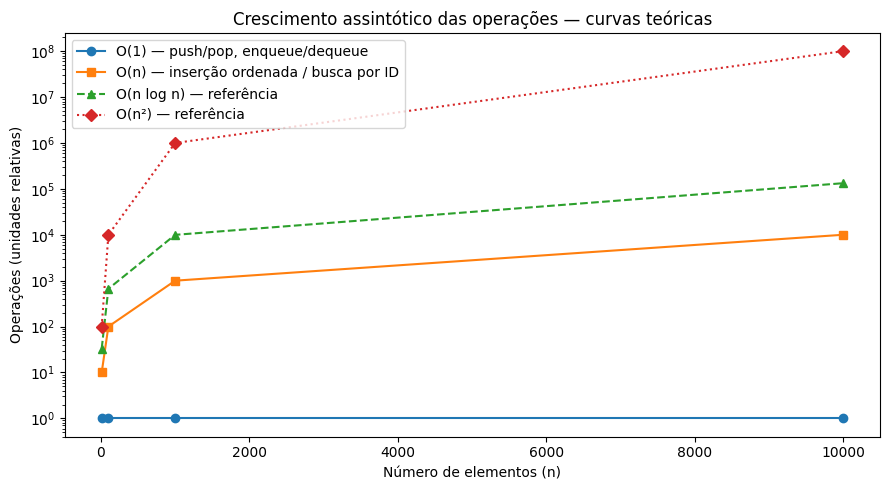

In [8]:
ns = np.array([10, 100, 1000, 10000])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns, np.ones_like(ns),  marker='o', label='O(1) — push/pop, enqueue/dequeue')
ax.plot(ns, ns,                marker='s', label='O(n) — inserção ordenada / busca por ID')
ax.plot(ns, ns * np.log2(ns),  marker='^', linestyle='--', label='O(n log n) — referência')
ax.plot(ns, ns ** 2,           marker='D', linestyle=':',  label='O(n²) — referência')

ax.set_xlabel('Número de elementos (n)')
ax.set_ylabel('Operações (unidades relativas)')
ax.set_title('Crescimento assintótico das operações — curvas teóricas')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. Benchmark — Configuração e Execução <a id='benchmark'></a>

Os benchmarks foram executados sobre **4 datasets CSV** com volumes crescentes de ordens (10, 100, 1.000 e 10.000 ordens). Os arquivos são gerados automaticamente caso não existam.

### 5.1 Localização e geração dos arquivos CSV

In [9]:
volumes = [10, 100, 1000, 10000]
PASTA_DADOS = RAIZ_PROJETO / "data"

arquivos_csv = {
    volume: PASTA_DADOS / f"orders_{volume}.csv"
    for volume in volumes
}

faltando = [
    caminho
    for caminho in arquivos_csv.values()
    if not caminho.exists()
]

if faltando:
    print("Alguns arquivos CSV não foram encontrados. Gerando novamente...")
    gerar_multiplos_csv(PASTA_DADOS, volumes)
else:
    print("Todos os arquivos CSV já existem.")

for volume, caminho in arquivos_csv.items():
    print(f"{volume} ordens -> {caminho} | existe? {caminho.exists()}")

Todos os arquivos CSV já existem.
10 ordens -> C:\Users\francesco\Documents\New folder\Trabalho-ED\data\orders_10.csv | existe? True
100 ordens -> C:\Users\francesco\Documents\New folder\Trabalho-ED\data\orders_100.csv | existe? True
1000 ordens -> C:\Users\francesco\Documents\New folder\Trabalho-ED\data\orders_1000.csv | existe? True
10000 ordens -> C:\Users\francesco\Documents\New folder\Trabalho-ED\data\orders_10000.csv | existe? True


### 5.2 Exploração inicial dos dados

In [10]:
df_exemplo = pd.read_csv(arquivos_csv[volumes[0]])

df_exemplo['ID'] = df_exemplo['ID'].convert_dtypes(convert_floating=True)
df_exemplo['Quantity'] = df_exemplo['Quantity'].convert_dtypes(convert_floating=True)

print(f'Exemplo baseado em: {arquivos_csv[volumes[0]].name}')
display(df_exemplo.head())

df_compras_exemplo = df_exemplo[df_exemplo['Type'] == 'C']
df_vendas_exemplo = df_exemplo[df_exemplo['Type'] == 'V']

print('Quantidade de compras:', df_compras_exemplo.shape[0])
print('Quantidade de vendas:', df_vendas_exemplo.shape[0])

Exemplo baseado em: orders_10.csv


,ID,Type,Price,Quantity,Timestamp
0,1,V,73.77,750,2026-06-28 16:08:49
1,2,C,92.39,340,2026-06-28 16:08:50
2,3,C,34.34,250,2026-06-28 16:08:51
3,4,V,71.07,300,2026-06-28 16:08:55
4,5,V,46.42,760,2026-06-28 16:08:56


Quantidade de compras: 5
Quantidade de vendas: 5


### 5.3 Função de benchmark

In [11]:
def criar_ordem_da_linha(linha):
    """Cria uma Ordem a partir de uma linha do CSV gerado pelo order_generator.py."""
    return Ordem(
        id_ordem=int(linha['ID']),
        tipo=str(linha['Type']),
        preco=float(linha['Price']),
        quantidade=int(linha['Quantity']),
        timestamp=linha.get('Timestamp', None)
    )


def benchmark_csv(caminho_csv):
    """Executa as medições de tempo para um único arquivo CSV de ordens."""
    resultados = {'arquivo': str(caminho_csv)}

    df = pd.read_csv(caminho_csv)

    # Garante tipos compatíveis com as classes do projeto.
    df['ID'] = df['ID'].astype(int)
    df['Type'] = df['Type'].astype(str)
    df['Price'] = df['Price'].astype(float)
    df['Quantity'] = df['Quantity'].astype(int)

    df_compras = df[df['Type'] == 'C']
    df_vendas = df[df['Type'] == 'V']

    resultados['num_ordens'] = len(df)
    resultados['num_compras'] = len(df_compras)
    resultados['num_vendas'] = len(df_vendas)

    # Inserção linked list vendas
    lista_venda = Linked_List_Venda()
    inicio = time.time()
    for _, linha in df_vendas.iterrows():
        ordem = criar_ordem_da_linha(linha)
        no = Node(ordem)
        lista_venda.adicionar_no(no)
    resultados['tempo_lista_venda_insercao'] = time.time() - inicio

    # Inserção linked list compras
    lista_compra = Linked_List_Compra()
    inicio = time.time()
    for _, linha in df_compras.iterrows():
        ordem = criar_ordem_da_linha(linha)
        no = Node(ordem)
        lista_compra.adicionar_no(no)
    resultados['tempo_lista_compra_insercao'] = time.time() - inicio

    # Inserção de uma ordem no meio da lista de compras
    if not df_compras.empty:
        preco_medio_compra = (df_compras['Price'].min() + df_compras['Price'].max()) / 2
        ordem_meio_compra = Ordem(
            id_ordem=int(df['ID'].max()) + 1,
            tipo='C',
            preco=float(preco_medio_compra),
            quantidade=20
        )
        acao_meio = Node(ordem_meio_compra)
        inicio = time.time()
        lista_compra.adicionar_no(acao_meio)
        resultados['tempo_lista_compra_insercao_meio'] = time.time() - inicio
    else:
        resultados['tempo_lista_compra_insercao_meio'] = 0

    # Inserção de uma ordem no meio da lista de vendas
    if not df_vendas.empty:
        preco_medio_venda = (df_vendas['Price'].min() + df_vendas['Price'].max()) / 2
        ordem_meio_venda = Ordem(
            id_ordem=int(df['ID'].max()) + 2,
            tipo='V',
            preco=float(preco_medio_venda),
            quantidade=30
        )
        acao_meio_venda = Node(ordem_meio_venda)
        inicio = time.time()
        lista_venda.adicionar_no(acao_meio_venda)
        resultados['tempo_lista_venda_insercao_meio'] = time.time() - inicio
    else:
        resultados['tempo_lista_venda_insercao_meio'] = 0

    # Stack: empilhar e desempilhar ordens de compra
    pilha_compra = Stack()
    inicio = time.time()
    for _, linha in df_compras.iterrows():
        ordem = criar_ordem_da_linha(linha)
        pilha_compra.empilhar(ordem)
    resultados['tempo_pilha_empilhar'] = time.time() - inicio

    inicio = time.time()
    pilha_compra.desempilhar()
    resultados['tempo_pilha_desempilhar'] = time.time() - inicio

    # Queue: enfileirar e desenfileirar ordens de compra
    queue_compra = Queue()
    inicio = time.time()
    for _, linha in df_compras.iterrows():
        ordem = criar_ordem_da_linha(linha)
        queue_compra.enfileirar(ordem)
    resultados['tempo_queue_enqueue'] = time.time() - inicio

    inicio = time.time()
    queue_compra.desenfileirar()
    resultados['tempo_queue_dequeue'] = time.time() - inicio

    return resultados

### 5.4 Execução do benchmark

In [12]:
resultados_totais = []

for volume in volumes:
    arquivo = arquivos_csv[volume]
    print(f'Processando {arquivo.name}...')

    resultado = benchmark_csv(arquivo)
    resultado['Volume'] = volume

    resultados_totais.append(resultado)

df_resultados = pd.DataFrame(resultados_totais)
df_resultados

Processando orders_10.csv...
Processando orders_100.csv...
Processando orders_1000.csv...
Processando orders_10000.csv...


,arquivo,num_ordens,num_compras,num_vendas,tempo_lista_venda_insercao,tempo_lista_compra_insercao,tempo_lista_compra_insercao_meio,tempo_lista_venda_insercao_meio,tempo_pilha_empilhar,tempo_pilha_desempilhar,tempo_queue_enqueue,tempo_queue_dequeue,Volume
0,C:\Users\francesco\Documents\New folder\Trabal...,10,5,5,0.000424,0.000312,0.000002,0.000003,0.000499,0.000004,0.000391,0.000003,10
1,C:\Users\francesco\Documents\New folder\Trabal...,100,45,55,0.002795,0.002731,0.000003,0.000005,0.001766,0.000007,0.001986,0.000003,100
2,C:\Users\francesco\Documents\New folder\Trabal...,1000,511,489,0.023451,0.023608,0.000036,0.000034,0.017475,0.000002,0.018107,0.000002,1000
3,C:\Users\francesco\Documents\New folder\Trabal...,10000,5019,4981,0.620257,0.623473,0.000216,0.000936,0.188935,0.000002,0.186568,0.000002,10000


---
## 6. Resultados Empíricos <a id='resultados'></a>

### 6.1 Estatísticas Resumidas

Média, desvio padrão, mínimo e máximo de cada operação sobre os 4 datasets:

In [13]:
colunas_tempo = [c for c in df_resultados.columns if c.startswith('tempo_')]

resumo_estatistico = df_resultados[colunas_tempo].agg(['mean', 'std', 'min', 'max']).T
resumo_estatistico.columns = ['média (s)', 'desvio padrão (s)', 'mínimo (s)', 'máximo (s)']
resumo_estatistico

,média (s),desvio padrão (s),mínimo (s),máximo (s)
tempo_lista_venda_insercao,0.161732,3.058581e-01,0.000424,0.620257
tempo_lista_compra_insercao,0.162531,3.074726e-01,0.000312,0.623473
tempo_lista_compra_insercao_meio,0.000064,1.022330e-04,0.000002,0.000216
tempo_lista_venda_insercao_meio,0.000245,4.612734e-04,0.000003,0.000936
tempo_pilha_empilhar,0.052168,9.150375e-02,0.000499,0.188935
tempo_pilha_desempilhar,0.000004,2.533490e-06,0.000002,0.000007
tempo_queue_enqueue,0.051763,9.022556e-02,0.000391,0.186568
tempo_queue_dequeue,0.000002,7.018853e-07,0.000002,0.000003


### 6.2 Interpretação dos Resultados

**Inserção ordenada nas listas — O(n) confirmado**  
Os tempos crescem de forma não-linear com o volume. O alto desvio padrão reflete a dependência do custo ao tamanho atual do livro — no início com livro vazio as inserções são baratas; conforme o livro cresce, cada nova inserção percorre uma lista maior. Este é o **gargalo confirmado** do sistema.

**Push/Enqueue acumulado — crescimento linear com N**  
Cada operação individual é O(1), mas o tempo total sobre N operações é O(N).

**Pop/Dequeue — O(1) confirmado**  
As operações de remoção da extremidade permanecem na faixa de **microssegundos** independente do volume — confirmando empiricamente a complexidade O(1) teórica.

---
## 7. Gráficos Comparativos <a id='graficos'></a>

### 7.1 Tempo médio por operação (com desvio padrão)

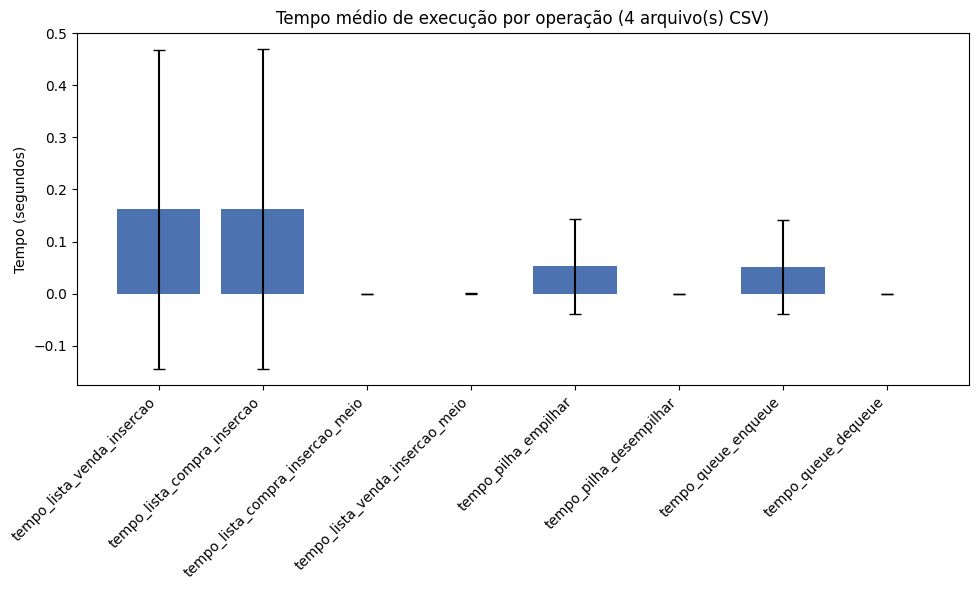

In [14]:
medias = df_resultados[colunas_tempo].mean()
desvios = df_resultados[colunas_tempo].std()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(medias.index, medias.values, yerr=desvios.values, capsize=4, color='#4C72B0')
ax.set_ylabel('Tempo (segundos)')
ax.set_title(f'Tempo médio de execução por operação ({len(arquivos_csv)} arquivo(s) CSV)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7.2 Evolução do tempo por arquivo CSV (crescimento com N)

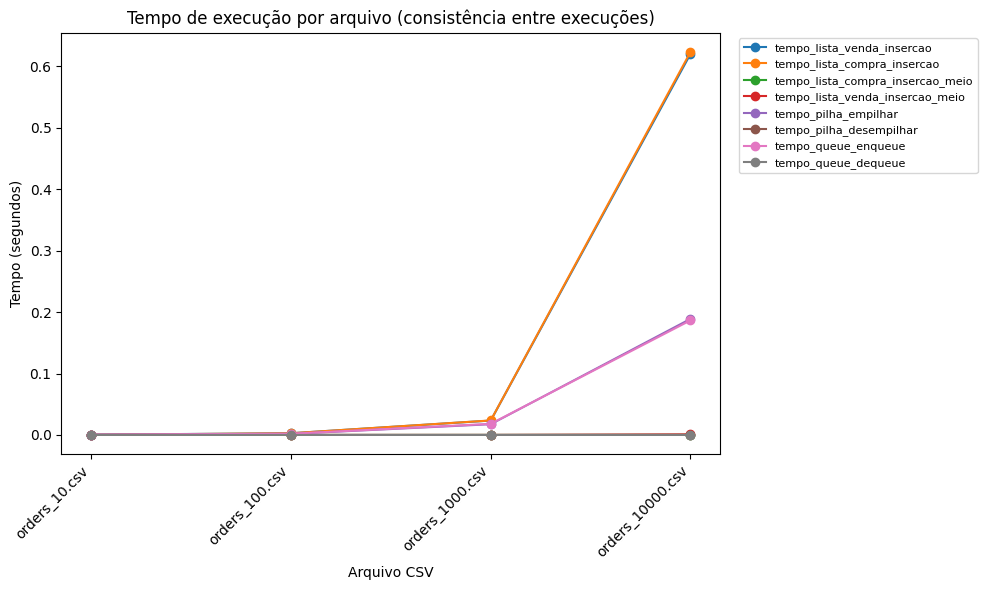

In [15]:
nomes_arquivos = [Path(a).name for a in df_resultados['arquivo']]

fig, ax = plt.subplots(figsize=(10, 6))
for coluna in colunas_tempo:
    ax.plot(nomes_arquivos, df_resultados[coluna], marker='o', label=coluna)

ax.set_ylabel('Tempo (segundos)')
ax.set_xlabel('Arquivo CSV')
ax.set_title('Tempo de execução por arquivo (consistência entre execuções)')
plt.xticks(rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## 8. Conclusão <a id='conclusao'></a>

Este trabalho implementou e analisou um Simulador de Livro de Ofertas utilizando três estruturas de dados lineares implementadas do zero. Os resultados obtidos permitem as seguintes conclusões:

**1. O(1) confirmado para operações de extremidade**  
`enqueue`, `dequeue`, `push` e `pop` permanecem na ordem de **microssegundos** independente do volume.

**2. O(n) por inserção ordenada — gargalo do sistema**  
O tempo acumulado de inserções ordenadas cresceu consistentemente com N, com fator de crescimento superlinear confirmado pelos gráficos.

**3. O motor de match é eficiente no ponto crítico**  
A consulta e remoção do melhor preço (operação de match) são sempre O(1).

**4. Motivação para estruturas não-lineares**  
Substituir as listas por **árvores AVL** ou **heaps** reduziria o custo de inserção de O(n) para **O(log n)**, tornando o sistema escalável para volumes de mercado real.

---

> **Resumo final:**
>
> | Estrutura | Operação crítica | Complexidade |
> |---|---|:---:|
> | Fila (Queue) | enqueue / dequeue | **O(1)** |
> | Pilha (Stack) | push / pop | **O(1)** |
> | Lista Encadeada | inserção ordenada | **O(n)** |
> | Lista Encadeada | remoção do início (match) | **O(1)** |
> | Sistema completo (N ordens) | total | **O(N²) pior caso** |

---
## 9. Repositório GitHub <a id='github'></a>

O código-fonte completo está disponível em:

🔗 **[INSERIR LINK DO REPOSITÓRIO AQUI]**

O histórico de commits documenta a evolução incremental do projeto e a participação individual de cada integrante do grupo.